In [347]:
import gc
import numpy as np  
import pandas as pd  
import seaborn as sns  
import warnings 
import nltk
import string

import matplotlib.pyplot as plt  

from time import time
from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

warnings.filterwarnings('ignore') 
tqdm.pandas()
nltk.download('stopwords')
nltk.download('punkt')
%matplotlib inline

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dima\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dima\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [314]:
# Загрузка данных
books = pd.read_csv('data/books.csv')
book_tags = pd.read_csv('data/book_tags.csv')
ratings = pd.read_csv('data/ratings.csv')
tags = pd.read_csv('data/tags.csv')

# <center> **Подготовка данных**

In [315]:
# Список числовых признаков
books_numeric = [x for x in books.columns if books[x].dtype != 'object']

# Проверим диапазон значений
for col in books_numeric:
    print(f'{col}: {books[col].min()} - {books[col].max()}')
    
    
# Преобразование типов данных
# uint16: books_count
# int16: original_publication_year
# uint32: остальные целочисленные, кроме идентификаторов
# int64: isbn13
# float16: average_rating
books['books_count'] = books['books_count'].astype('uint16')
books['original_publication_year'] = books['original_publication_year'].astype('Int16')
books['isbn13'] = books['isbn13'].astype('Int64')
books['average_rating'] = books['average_rating'].astype('float16')
for col in ['books_count', 'ratings_count', 'work_ratings_count', 'work_text_reviews_count', 'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5']:
    books[col] = books[col].astype('int64')


id: 1 - 10000
book_id: 1 - 33288638
best_book_id: 1 - 35534230
work_id: 87 - 56399597
books_count: 1 - 3455
isbn13: 195170342.0 - 9790007672390.0
original_publication_year: -1750.0 - 2017.0
average_rating: 2.47 - 4.82
ratings_count: 2716 - 4780653
work_ratings_count: 5510 - 4942365
work_text_reviews_count: 3 - 155254
ratings_1: 11 - 456191
ratings_2: 30 - 436802
ratings_3: 323 - 793319
ratings_4: 750 - 1481305
ratings_5: 754 - 3011543


In [316]:
# book_tags['count'] -> uint32
book_tags['count'] = book_tags['count'].astype('uint32')
# ratings['rating'] -> uint8
ratings['rating'] = ratings['rating'].astype('uint8')

In [317]:
# Из books удалим признаки со ссылками на изображения
books = books.drop(['image_url', 'small_image_url'], axis=1)

In [318]:
# Проверка на наличие полных дубликатов
print(f'Количество дубликатов в books: {books.duplicated().sum()}')
print(f'Количество дубликатов в book_tags: {book_tags.duplicated().sum()}')
print(f'Количество дубликатов в tags: {tags.duplicated().sum()}')
print(f'Количество дубликатов в ratings: {ratings.duplicated().sum()}')

Количество дубликатов в books: 0
Количество дубликатов в book_tags: 6
Количество дубликатов в tags: 0
Количество дубликатов в ratings: 1644


In [319]:
# Дубликаты в book_tags
book_tags[book_tags.duplicated(keep=False)]

,goodreads_book_id,tag_id,count
159370,22369,25148,4
159371,22369,25148,4
265127,52629,10094,1
265128,52629,10094,1
265139,52629,2928,1
265140,52629,2928,1
265154,52629,13272,1
265155,52629,13272,1
265186,52629,13322,1
265187,52629,13322,1


In [320]:
print(f'Количество записей до удаления: {book_tags.shape[0]}')
# Удалим полные дубликаты в book_tags
book_tags.drop_duplicates(inplace=True)
print(f'Количество дубликатов в book_tags: {book_tags.duplicated().sum()}')
print(f'Количество записей после удаления: {book_tags.shape[0]}')

Количество записей до удаления: 999912
Количество дубликатов в book_tags: 0
Количество записей после удаления: 999906


In [321]:
# Дополнительно проверим дубликаты по признакам идентификаторов в ratings
print(f'Количество дубликатов в ratings по признакам book_id и user_id: {ratings.duplicated(subset=["book_id", "user_id"]).sum()}')

Количество дубликатов в ratings по признакам book_id и user_id: 2278


In [322]:
print(f'Количество записей до удаления: {ratings.shape[0]}')
# Удаление дубликатов, оставляя последнюю оценку
ratings = ratings.drop_duplicates(subset=['book_id', 'user_id'], keep='last')
print(f'Количество дубликатов в ratings: {ratings.duplicated().sum()}')
print(f'Количество записей после удаления: {ratings.shape[0]}')

Количество записей до удаления: 981756
Количество дубликатов в ratings: 0
Количество записей после удаления: 979478


In [323]:
# Удаляем пропуски в books
books = books.dropna(subset='original_title')

In [324]:
books.isnull().sum()

id                              0
book_id                         0
best_book_id                    0
work_id                         0
books_count                     0
isbn                          557
isbn13                        455
authors                         0
original_publication_year       6
original_title                  0
title                           0
language_code                1005
average_rating                  0
ratings_count                   0
work_ratings_count              0
work_text_reviews_count         0
ratings_1                       0
ratings_2                       0
ratings_3                       0
ratings_4                       0
ratings_5                       0
dtype: int64

# <center> **Обучение моделей**

## Train / test разделение

+ Считаем сколько оценок поставил каждый пользователь
+ Отбираем только тех, у кого оценок больше 5 (остальные идут в выборку для холодного старта)
+ У каждого пользователя случайным образом выбираем 20% записей (test)
+ Остальные записи идут в train

In [325]:
# Отбираем пользователей, у которых больше 5 оценок
users = ratings['user_id'].value_counts()
active_users = users[users > 5].index
print(len(active_users))

# Отбираем пользователей для холодного старта
cold_start_users = set(ratings['user_id'].unique()).difference(set(active_users))   
print(f'Количество пользователей в группе для холодного старта: {len(cold_start_users)}')
print(f'Количество активных пользователей: {len(active_users)}')

# Отфильтровываем датафреймы
hot_ratings = ratings[ratings['user_id'].isin(active_users)]
cold_ratings = ratings[ratings['user_id'].isin(cold_start_users)]

# Выбираем 20% записей в тест
def sample_test(group, test_size=0.2):
    n_users = max(1, int(len(group) * test_size))
    return group.sample(n=n_users)

test_groups = hot_ratings.groupby('user_id', group_keys=False).progress_apply(sample_test)
test_idx = test_groups.index   
    
# Фильтруем датафреймы
test_df = hot_ratings.loc[test_idx]
train_df = hot_ratings.drop(test_idx) 

print(f'Размернось cold start: {cold_ratings.shape}')
print(f'Размернось train: {train_df.shape}')
print(f'Размернось test: {test_df.shape}')

32439
Количество пользователей в группе для холодного старта: 20985
Количество активных пользователей: 32439


100%|██████████| 32439/32439 [00:06<00:00, 5404.38it/s]

Размернось cold start: (64973, 3)
Размернось train: (744473, 3)
Размернось test: (170032, 3)


## <center> **Этап 1. Улучшенная подготовка данных**

#### Признаки пользователей: средний рейтинг, количество оценок, активность.

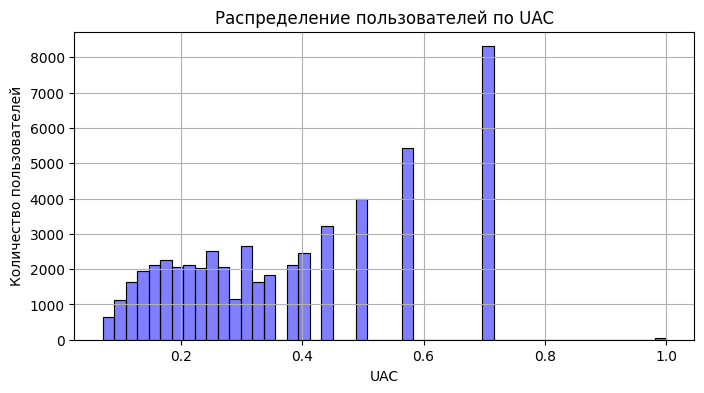

In [326]:
# Средний рейтинг и количество оценок
user_features = ratings.groupby('user_id').agg(
        user_avg_rating=('rating', 'mean'),
        user_rating_count=('book_id', 'count')
    ).reset_index()

# Активность пользователя
# Формула UAC -> 1/sqrt(d1 * d2), только для одного пользователя
user_features['user_activity_count'] = 1 / np.sqrt(user_features['user_rating_count'])

plt.figure(figsize=(8, 4))
hist = sns.histplot(user_features, x='user_activity_count', color='blue', alpha=0.5)
hist.set_title('Распределение пользователей по UAC')
hist.set_xlabel('UAC')
hist.set_ylabel('Количество пользователей')
hist.grid()

In [327]:
user_features.head()

,user_id,user_avg_rating,user_rating_count,user_activity_count
0,1,3.666667,3,0.577350
1,2,4.333333,3,0.577350
2,3,1.000000,2,0.707107
3,4,4.000000,3,0.577350
4,5,4.200000,5,0.447214


#### Признаки книг: популярность, разнообразие оценок, тематические категории.

In [328]:
# Популярность книги -> взвешенный рейтинг
books_popularity = books[['work_ratings_count', 'work_text_reviews_count']]

# Нормализуем данные, так как шкалы разные
books_popularity['pop_log_ratings'] = np.log1p(books_popularity['work_ratings_count'])
books_popularity['pop_log_reviews'] = np.log1p(books_popularity['work_text_reviews_count'])
# Смешиваем: 70% веса количеству оценок, 30% текстовым отзывам
books_popularity['popularity_index'] = (books_popularity['pop_log_ratings'] * 0.7) + (books_popularity['pop_log_reviews'] * 0.3)
books_popularity = books_popularity.drop(['work_ratings_count', 'work_text_reviews_count', 'pop_log_ratings', 'pop_log_reviews'], axis=1)
books_popularity = books_popularity.reset_index(drop=True)

In [329]:
# Разнообразие оценок
# Чем выше энтропия, тем выше разнообразие
def entrophy_calc(row):
    '''Вычисляет энтропию Шеннона по количеству
    выставленных оценок каждого типа'''
    count = row[['ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5']]    
    total = np.sum(count)
    probs = count / total    
    probs_fl = np.array([float(x) for x in probs])    
    return -np.sum(probs_fl * np.log2(probs_fl))    

books_diversity = books.apply(entrophy_calc, axis=1)
books_diversity = books_diversity.reset_index(drop=True)

In [330]:
books_features = pd.concat([books_popularity, pd.Series(books_diversity, name='books_diversity')], axis=1)
books_features.head()

,popularity_index,books_diversity
0,14.375196,1.573085
1,14.139923,1.450875
2,14.065076,2.193653
3,13.872987,1.677672
4,13.642656,1.964913


In [331]:
np.random.seed(42)
# Тематические категории -> BERTopic
all_stop_words = set()
for lang in stopwords.fileids():
    all_stop_words.update(stopwords.words(lang))

def remove_stopwords(text):
    '''Убирает стоп-слова и пунктуацию из текста'''
    tokens = word_tokenize(text.lower())    
    tokens = [word for word in tokens if word not in all_stop_words and word not in string.punctuation]
    return ' '.join(tokens)

docs = books['original_title'].apply(remove_stopwords)
bert_model = BERTopic()
topics, probs = bert_model.fit_transform(docs)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 832.97it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [332]:
topics_info = bert_model.get_topic_info()
display(topics_info.head(10))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2531,-1_story_pilgrim_frog_beautiful,"[story, pilgrim, frog, beautiful, scott, nt, v...","[love story, scott pilgrim volume 3 scott pilg..."
1,0,413,0_llama_storia_histoire_frida,"[llama, storia, histoire, frida, amor, leben, ...","[llama llama mad mama, män hatar kvinnor flick..."
2,1,167,1_shoutin_lon_hhhh_fuckup,"[shoutin, lon, hhhh, fuckup, finally, sign, , ...","[finally, hhhh, lon]"
3,2,133,2_desu_nto_1q84_ichikyhachiyon,"[desu, nto, 1q84, ichikyhachiyon, kuroshitsuji...","[デスノート 7 desu nōto zero 零, デスノート 2 desu nōto g..."
4,3,128,3_god_jesus_preacher_gods,"[god, jesus, preacher, gods, faith, holy, bibl...","[conversations god uncommon dialogue book 3, c..."
5,4,119,4_scarlet_elizabeth_miss_amelia,"[scarlet, elizabeth, miss, amelia, duchess, ma...","[study scarlet, scarlet, scarlet]"
6,5,78,5_hatralar_tibet_alf_cinta,"[hatralar, tibet, alf, cinta, chalk, dvn, alqu...","[धर्मपद dhammapada, sieben jahre tibet, abnkkb..."
7,6,75,6_darkness_darkest_dark_kiss,"[darkness, darkest, dark, kiss, blackout, path...","[darkness night, darkness, darkness]"
8,7,74,7_food_recipes_cookbook_cook,"[food, recipes, cookbook, cook, kitchen, cooki...",[art simple food notes recipes delicious revol...
9,8,73,8_girl_girls_gilmore_samantha,"[girl, girls, gilmore, samantha, pretty, accen...","[girl, girl, girl]"


In [333]:
print('books shape', books.shape)
print('len topics', len(topics))

books shape (9415, 21)
len topics 9415


In [334]:
# формируем признаки тем
book_topic = pd.concat([
                        books['book_id'].reset_index(drop=True),
                        pd.Series(topics, name='topic_id')
                                                        ], axis=1)
def get_embedding(topic_id):    
    return bert_model.topic_embeddings_[topic_id]

book_topic['topic_embedding'] = book_topic['topic_id'].apply(get_embedding)

In [335]:
books_features = pd.concat([books_features, book_topic], axis=1)
books_features.head()

,popularity_index,books_diversity,book_id,topic_id,topic_embedding
0,14.375196,1.573085,2767052,232,"[-0.032385066, -0.045018073, 0.007851143, 0.03..."
1,14.139923,1.450875,3,68,"[-0.0012532048, 0.041199405, -0.008950223, 0.0..."
2,14.065076,2.193653,41865,154,"[-0.04740456, 0.040336054, -0.0075503695, -0.0..."
3,13.872987,1.677672,2657,-1,"[-0.004266885, 0.019561592, -0.018037725, 0.04..."
4,13.642656,1.964913,4671,-1,"[-0.004266885, 0.019561592, -0.018037725, 0.04..."


#### Признаки взаимодействий: схожесть с историей пользователя.

In [359]:
tqdm.pandas(desc='Группировка тегов')
gc.collect()

# Объединяем теги с их названиями
book_tags_joined = book_tags.merge(tags[['tag_id', 'tag_name']], on='tag_id')
# Группируем теги в строки (без раздувания, для экономии памяти)
book_descriptions = (
    book_tags_joined
    .groupby('goodreads_book_id')['tag_name']
    .progress_apply(lambda x: ' '.join(x.astype(str)))
    .reset_index(name='tag_str')
)
# Очистка памяти
del book_tags_joined 
gc.collect()

# Векторизация книг (Content Space)
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', dtype=np.float32)
item_vectors = tfidf.fit_transform(book_descriptions['tag_str'])
item_vectors = normalize(item_vectors)

# Маппинг: book_id в базе -> индекс строки в матрице item_vectors
book_id_to_idx = {id: i for i, id in enumerate(book_descriptions['goodreads_book_id'])}

# Создание профилей пользователей (User Profiles)
top_ratings = ratings[ratings['rating'] >= 4].copy()
# Оставляем только те книги, для которых у нас есть текстовое описание (теги)
top_ratings = top_ratings[top_ratings['book_id'].isin(book_id_to_idx)]

# фиксируем размерности
num_books = item_vectors.shape[0]           
num_users = ratings['user_id'].max() + 1      
rows = top_ratings['user_id'].values
cols = top_ratings['book_id'].map(book_id_to_idx).values
data = top_ratings['rating'].values

# Создаем разреженную матрицу User-Item 
user_item_matrix = csr_matrix((data, (rows, cols)), shape=(num_users, num_books))
# Считаем профили: перемножаем взаимодействия на признаки книг
user_profiles = user_item_matrix.dot(item_vectors)
user_profiles = normalize(user_profiles) 

# Функция для  расчета схожести 
def get_similarity_batch(user_ids, book_ids, user_profiles, item_vectors, book_id_to_idx):    
    # Получаем индексы книг (те, что не найдены, помечаем как -1)
    b_indices = np.array([book_id_to_idx.get(bid, -1) for bid in book_ids])    
    # Маска для существующих книг (чтобы избежать ошибок индексации)
    valid_mask = b_indices != -1    
    # Подготавливаем массив для результатов
    sims = np.zeros(len(user_ids))    
    if valid_mask.any():
        # Извлекаем векторы пользователей и книг только для валидных индексов
        u_vecs = user_profiles[user_ids[valid_mask]]
        b_vecs = item_vectors[b_indices[valid_mask]]        
        # Скалярное произведение нормализованных векторов (Cosine Similarity)        
        batch_sims = np.array(u_vecs.multiply(b_vecs).sum(axis=1)).flatten()
        sims[valid_mask] = batch_sims
        
    return sims

# Финальный расчет признака для всей таблицы ratings
ratings['history_similarity'] = get_similarity_batch(
    user_ids=ratings['user_id'].values,     
    book_ids=ratings['book_id'].values,    
    user_profiles=user_profiles,           
    item_vectors=item_vectors,            
    book_id_to_idx=book_id_to_idx          
)
gc.collect()

Группировка тегов: 100%|██████████| 10000/10000 [00:00<00:00, 16339.83it/s]


0

In [360]:
ratings['history_similarity']

0         0.842228
1         0.355676
2         0.511273
3         0.711274
4         0.629901
            ...   
981751    0.000000
981752    0.000000
981753    0.000000
981754    0.000000
981755    0.000000
Name: history_similarity, Length: 979478, dtype: float64

In [353]:
# Объединяем теги
book_tags_joined = book_tags.merge(tags[['tag_id', 'tag_name']], on='tag_id')

book_descriptions = (
    book_tags_joined
    .groupby('goodreads_book_id')['tag_name']
    .apply(lambda x: ' '.join(x.astype(str)))
    .reset_index(name='tag_str')
)

# Сортируем по goodreads_book_id
book_descriptions = book_descriptions.sort_values('goodreads_book_id').reset_index(drop=True)

# Векторизуем (TF-IDF)
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', dtype=np.float32)
item_vectors = tfidf.fit_transform(book_descriptions['tag_str'])
item_vectors = normalize(item_vectors)

# Маппинг: goodreads_book_id -> индекс в item_vectors
book_id_to_idx = {id: i for i, id in enumerate(book_descriptions['goodreads_book_id'])}

# Фильтруем оценки: только те, что есть в book_id_to_idx
top_ratings = ratings[ratings['rating'] >= 4].copy()
top_ratings = top_ratings[top_ratings['book_id'].isin(book_id_to_idx.keys())]

# Создаем разреженную матрицу (User x Item)
rows = top_ratings['user_id']
cols = top_ratings['book_id'].map(book_id_to_idx)
data = top_ratings['rating']
user_item_matrix = csr_matrix((data, (rows, cols)))

# Умножаем: (User-Item) @ (Item-Tags) = (User-Tags)
user_profiles = user_item_matrix.dot(item_vectors)
user_profiles = normalize(user_profiles)

ValueError: matmul: dimension mismatch with signature (n,k=812),(k=10000,m)->(n,m)